1. На основе учебного ноутбука проведите финальную подготовку данных. Иизмените количество сегментирующих классов с `16` на `5`.

2. Проведите суммарно не менее `10` экспериментов и визуализируйте их результаты (включая точность обучения сетей на одинаковом количестве эпох, например, на `7`):

  - изменив `filters` в сверточных слоях
  - изменив `kernel_size` в сверточных слоях
  - изменив активационную функцию в скрытых слоях с `relu` на `linear` или/и `selu`, `elu`.


**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

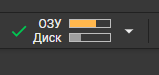



Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

Перед выполнением задания, пожалуйста, запустите ячейку `Подготовка` ниже:

## Подготовка

### Импорт библиотек

In [ ]:
 # Импортируем модели keras: Model
from tensorflow.keras.models import Model

 # Импортируем стандартные слои keras
from tensorflow.keras.layers import Input, Conv2DTranspose, concatenate, Activation
from tensorflow.keras.layers import MaxPooling2D, Conv2D, BatchNormalization, UpSampling2D

# Импортируем оптимизатор Adam
from tensorflow.keras.optimizers import Adam

# Импортируем модуль pyplot библиотеки matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем модуль image для работы с изображениями
from tensorflow.keras.preprocessing import image

# Импортируем библиотеку numpy
import numpy as np

# Импортируем методделения выборки
from sklearn.model_selection import train_test_split

# загрузка файлов по HTML ссылке
import gdown

# Для работы с файлами
import os

# Для генерации случайных чисел
import random

import time

# импортируем модель Image для работы с изображениями
from PIL import Image

# очистка ОЗУ
import gc

### Загрузка датасета

грузим и распаковываем архив картинок

In [ ]:
# Загрузка датасета из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)
#gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_512x384.zip', None, quiet=False)

!unzip -q 'construction_256x192.zip' # распоковываем архив

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:10<00:00, 20.3MB/s]


In [ ]:
# Глобальные параметры

IMG_WIDTH = 192               # Ширина картинки
IMG_HEIGHT = 256              # Высота картинки
NUM_CLASSES = 16              # Задаем количество классов на изображении
TRAIN_DIRECTORY = 'train'     # Название папки с файлами обучающей выборки
VAL_DIRECTORY = 'val'         # Название папки с файлами проверочной выборки

Загрузим оригинальные изображения (код из лекции):

In [ ]:
train_images = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_images = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time()  # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_images.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/original',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающей выборке
print ('Количество изображений: ', len(train_images))

cur_time = time.time() # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(VAL_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_images.append(image.load_img(os.path.join(VAL_DIRECTORY+'/original',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочной выборке
print ('Количество изображений: ', len(val_images))

Обучающая выборка загружена. Время загрузки: 0.29c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.01c
Количество изображений:  100


Загрузим сегментированные изображения (код из лекции):

In [ ]:
train_segments = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_segments = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_segments.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/segment',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающем наборе сегментированных изображений
print ('Количество изображений: ', len(train_segments))

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(VAL_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_segments.append(image.load_img(os.path.join(VAL_DIRECTORY+'/segment',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочном наборе сегментированных изображений
print ('Количество изображений: ', len(val_segments))

Обучающая выборка загружена. Время загрузки: 0.26c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.02c
Количество изображений:  100


## Решение


### Решение на PyTorch

Задание: 16 → 5 классов сегментации, ≥10 экспериментов на одинаковом числе эпох (7), варьируем `filters`, `kernel_size`, `activation` (relu / linear / selu / elu).

**Экономия ОЗУ** (важно — иначе Colab падает):
- `X` хранится как `uint8`-тензор, нормализация `/255` — внутри `forward`;
- `Y` хранится как карта классов `int8 (N, H, W)`, не one-hot → в ~20 раз меньше;
- лосс `CrossEntropyLoss` (принимает индексы классов напрямую, one-hot не нужен);
- RGB→класс через одну LUT по 24-битному ключу;
- `DataLoader` с батчами + `gc.collect()` и `torch.cuda.empty_cache()` между экспериментами;
- размеры H/W берутся из реальной формы массива (в учебном `load_img(target_size=(IMG_WIDTH, IMG_HEIGHT))` keras читает как (H, W), фактически выходит 192×256).

In [ ]:
# 1. ПОДГОТОВКА ДАННЫХ: 16 -> 5 классов (PyTorch)
import numpy as np
import gc
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

NUM_CLASSES = 5

# Стандартная палитра 16 классов датасета construction_256x192.
CLASS_COLORS_16 = [
    (0,0,0),(128,0,0),(0,128,0),(128,128,0),
    (0,0,128),(128,0,128),(0,128,128),(128,128,128),
    (64,0,0),(192,0,0),(64,128,0),(192,128,0),
    (64,0,128),(192,0,128),(64,128,128),(192,128,128),
]

# 16 -> 5: 0=фон, 1=стены, 2=проёмы, 3=крыша, 4=прочее
MAP_16_TO_5 = np.array([
    0,
    1,1,1,
    2,2,2,2,
    3,3,3,3,
    4,4,4,4,
], dtype=np.int64)


def build_lut(colors):
    lut = np.full(256**3, 255, dtype=np.uint8)
    for idx,(r,g,b) in enumerate(colors):
        lut[(r<<16)|(g<<8)|b] = idx
    return lut


def seg_to_class5(seg, lut):
    s = np.asarray(seg, dtype=np.uint8)
    if s.ndim == 2:        s = np.stack([s]*3, axis=-1)
    if s.shape[-1] == 4:   s = s[..., :3]
    keys = ((s[...,0].astype(np.uint32)<<16) |
            (s[...,1].astype(np.uint32)<<8)  |
             s[...,2].astype(np.uint32))
    c16 = lut[keys]
    c16 = np.where(c16==255, 0, c16)
    return MAP_16_TO_5[c16].astype(np.int8)


#  X (uint8)
print('Готовим X...')
first = np.asarray(train_images[0], dtype=np.uint8)
H, W = first.shape[:2]
print(f'  Реальная форма картинки: H={H}, W={W}')

def stack_imgs(lst):
    out = np.empty((len(lst), H, W, 3), dtype=np.uint8)
    for i, im in enumerate(lst):
        a = np.asarray(im, dtype=np.uint8)
        if a.ndim == 2:      a = np.stack([a]*3, axis=-1)
        if a.shape[-1] == 4: a = a[..., :3]
        out[i] = a
    return out

x_train = stack_imgs(train_images)
x_val   = stack_imgs(val_images)
print(f'  x_train {x_train.shape} ~{x_train.nbytes/1024/1024:.1f} MB')
del train_images, val_images
gc.collect()

#  Y (int8 карта классов)
print('Готовим Y...')
LUT = build_lut(CLASS_COLORS_16)

probe = np.asarray(train_segments[0], dtype=np.uint8)
if probe.shape[-1]==4: probe = probe[...,:3]
pk = ((probe[...,0].astype(np.uint32)<<16)|(probe[...,1].astype(np.uint32)<<8)|probe[...,2].astype(np.uint32))
known = (LUT[pk]!=255).mean()
print(f'  Известных пикселей на первой маске: {known:.3f}')
if known < 0.5:
    print('  >> Палитра не подошла, определяем 16 цветов по частоте...')
    ka=[]
    for seg in train_segments:
        a=np.asarray(seg,dtype=np.uint8)
        if a.shape[-1]==4: a=a[...,:3]
        ka.append((((a[...,0].astype(np.uint32)<<16)|(a[...,1].astype(np.uint32)<<8)|a[...,2].astype(np.uint32))).ravel())
    ka=np.concatenate(ka); vals,cnt=np.unique(ka,return_counts=True)
    top=vals[np.argsort(-cnt)[:16]]
    LUT=np.full(256**3,255,dtype=np.uint8)
    for idx,k in enumerate(top): LUT[k]=idx
    del ka,vals,cnt,top; gc.collect()

y_train = np.empty((len(train_segments), H, W), dtype=np.int8)
for i,seg in enumerate(train_segments): y_train[i] = seg_to_class5(seg, LUT)
y_val = np.empty((len(val_segments), H, W), dtype=np.int8)
for i,seg in enumerate(val_segments):   y_val[i] = seg_to_class5(seg, LUT)
print(f'  y_train {y_train.shape} ~{y_train.nbytes/1024/1024:.1f} MB')

uniq,cnts = np.unique(y_train, return_counts=True)
print('  Классы в y_train:', dict(zip(uniq.tolist(), cnts.tolist())))

del train_segments, val_segments
gc.collect()

#  torch-тензоры (NCHW)
# X как uint8 NCHW; Y как long (CrossEntropy требует int64 индексы)
xt_train = torch.from_numpy(x_train).permute(0,3,1,2).contiguous()   # uint8
xt_val   = torch.from_numpy(x_val).permute(0,3,1,2).contiguous()
yt_train = torch.from_numpy(y_train.astype(np.int64))
yt_val   = torch.from_numpy(y_val.astype(np.int64))
print('xt_train', xt_train.shape, xt_train.dtype, '| yt_train', yt_train.shape, yt_train.dtype)

del x_train, x_val, y_train, y_val
gc.collect()


Device: cuda
Готовим X...
  Реальная форма картинки: H=192, W=256
  x_train (1900, 192, 256, 3) ~267.2 MB
Готовим Y...
  Известных пикселей на первой маске: 0.000
  >> Палитра не подошла, определяем 16 цветов по частоте...
  y_train (1900, 192, 256) ~89.1 MB
  Классы в y_train: {0: 47798941, 1: 32926001, 2: 9025507, 3: 2931560, 4: 706791}
xt_train torch.Size([1900, 3, 192, 256]) torch.uint8 | yt_train torch.Size([1900, 192, 256]) torch.int64


0

In [ ]:
# 2. U-Net на PyTorch с настраиваемыми параметрами
import torch.nn as nn

ACT = {
    'relu':   lambda: nn.ReLU(inplace=True),
    'elu':    lambda: nn.ELU(inplace=True),
    'selu':   lambda: nn.SELU(inplace=True),
    'linear': lambda: nn.Identity(),
}

class DoubleConv(nn.Module):
    def __init__(self, cin, cout, k, activation):
        super().__init__()
        p = k // 2
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, k, padding=p), nn.BatchNorm2d(cout), ACT[activation](),
            nn.Conv2d(cout, cout, k, padding=p), nn.BatchNorm2d(cout), ACT[activation](),
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, filters=16, kernel_size=3, activation='relu'):
        super().__init__()
        f = filters
        self.e1 = DoubleConv(3,    f,    kernel_size, activation)
        self.e2 = DoubleConv(f,    f*2,  kernel_size, activation)
        self.e3 = DoubleConv(f*2,  f*4,  kernel_size, activation)
        self.b  = DoubleConv(f*4,  f*8,  kernel_size, activation)
        self.pool = nn.MaxPool2d(2)
        self.up3 = nn.ConvTranspose2d(f*8, f*4, 2, stride=2)
        self.d3  = DoubleConv(f*8, f*4, kernel_size, activation)
        self.up2 = nn.ConvTranspose2d(f*4, f*2, 2, stride=2)
        self.d2  = DoubleConv(f*4, f*2, kernel_size, activation)
        self.up1 = nn.ConvTranspose2d(f*2, f,   2, stride=2)
        self.d1  = DoubleConv(f*2, f,   kernel_size, activation)
        self.out = nn.Conv2d(f, num_classes, 1)

    def forward(self, x):
        x = x.float() / 255.0          # нормализация внутри модели
        c1 = self.e1(x);              p1 = self.pool(c1)
        c2 = self.e2(p1);             p2 = self.pool(c2)
        c3 = self.e3(p2);             p3 = self.pool(c3)
        b  = self.b(p3)
        u3 = self.up3(b);  u3 = torch.cat([u3, c3], dim=1); d3 = self.d3(u3)
        u2 = self.up2(d3); u2 = torch.cat([u2, c2], dim=1); d2 = self.d2(u2)
        u1 = self.up1(d2); u1 = torch.cat([u1, c1], dim=1); d1 = self.d1(u1)
        return self.out(d1)            # логиты (B, C, H, W)

# Размеры кратны 8 (3 пулинга). Подгоним вход при необходимости.
_, _, IMG_H, IMG_W = xt_train.shape
print(f'Вход: ({IMG_H}, {IMG_W})')
PAD_H = (8 - IMG_H % 8) % 8
PAD_W = (8 - IMG_W % 8) % 8
print(f'Паддинг до кратности 8: +{PAD_H}h, +{PAD_W}w')


Вход: (192, 256)
Паддинг до кратности 8: +0h, +0w


In [ ]:
# 3. 10 ЭКСПЕРИМЕНТОВ (одинаковое число эпох = 7)
import torch.nn.functional as F
import time

EPOCHS = 7
BATCH_SIZE = 8

train_loader = DataLoader(TensorDataset(xt_train, yt_train),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(TensorDataset(xt_val,   yt_val),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

def pad_to8(t):
    if PAD_H or PAD_W:
        return F.pad(t, (0, PAD_W, 0, PAD_H))   # (left,right,top,bottom)
    return t

@torch.no_grad()
def evaluate(model):
    model.eval()
    tot_loss, correct, total = 0.0, 0, 0
    for xb, yb in val_loader:
        xb = pad_to8(xb.to(device, non_blocking=True))
        yb = pad_to8(yb.to(device, non_blocking=True))
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        tot_loss += loss.item() * xb.size(0)
        pred = logits.argmax(1)
        correct += (pred == yb).sum().item()
        total   += yb.numel()
    return tot_loss/len(val_loader.dataset), correct/total

def train_one(model):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    for ep in range(EPOCHS):
        model.train()
        tl, c, t = 0.0, 0, 0
        for xb, yb in train_loader:
            xb = pad_to8(xb.to(device, non_blocking=True))
            yb = pad_to8(yb.to(device, non_blocking=True))
            opt.zero_grad()
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            opt.step()
            tl += loss.item()*xb.size(0)
            c  += (logits.argmax(1)==yb).sum().item()
            t  += yb.numel()
        tr_loss, tr_acc = tl/len(train_loader.dataset), c/t
        v_loss, v_acc   = evaluate(model)
        hist['train_loss'].append(tr_loss); hist['train_acc'].append(tr_acc)
        hist['val_loss'].append(v_loss);    hist['val_acc'].append(v_acc)
        print(f'  эпоха {ep+1}/{EPOCHS}  train_loss={tr_loss:.4f} acc={tr_acc:.4f}'
              f' | val_loss={v_loss:.4f} acc={v_acc:.4f}')
    return hist

experiments = [
    {'name':'exp01','filters':16,'kernel_size':3,'activation':'relu'},
    {'name':'exp02','filters':32,'kernel_size':3,'activation':'relu'},
    {'name':'exp03','filters':8, 'kernel_size':3,'activation':'relu'},
    {'name':'exp04','filters':16,'kernel_size':5,'activation':'relu'},
    {'name':'exp05','filters':16,'kernel_size':7,'activation':'relu'},
    {'name':'exp06','filters':16,'kernel_size':3,'activation':'elu'},
    {'name':'exp07','filters':16,'kernel_size':3,'activation':'selu'},
    {'name':'exp08','filters':16,'kernel_size':3,'activation':'linear'},
    {'name':'exp09','filters':32,'kernel_size':5,'activation':'elu'},
    {'name':'exp10','filters':8, 'kernel_size':5,'activation':'selu'},
]

results = []
for cfg in experiments:
    print('\n' + '='*70)
    print(f"{cfg['name']}: filters={cfg['filters']}, kernel_size={cfg['kernel_size']}, "
          f"activation={cfg['activation']}")
    print('='*70)
    t0 = time.time()

    model = UNet(NUM_CLASSES, cfg['filters'], cfg['kernel_size'], cfg['activation']).to(device)
    hist = train_one(model)

    results.append({
        'name':cfg['name'], 'filters':cfg['filters'],
        'kernel_size':cfg['kernel_size'], 'activation':cfg['activation'],
        'train_acc':hist['train_acc'], 'val_acc':hist['val_acc'],
        'train_loss':hist['train_loss'], 'val_loss':hist['val_loss'],
        'final_val_acc':hist['val_acc'][-1], 'final_val_loss':hist['val_loss'][-1],
    })
    print(f"  время: {time.time()-t0:.1f}с")

    # Очистка ОЗУ/VRAM между экспериментами
    del model, hist
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\nВсе эксперименты завершены.')



exp01: filters=16, kernel_size=3, activation=relu
  эпоха 1/7  train_loss=1.0321 acc=0.6274 | val_loss=1.0151 acc=0.6304
  эпоха 2/7  train_loss=0.7541 acc=0.7273 | val_loss=0.9976 acc=0.6229
  эпоха 3/7  train_loss=0.6956 acc=0.7513 | val_loss=1.0244 acc=0.6385
  эпоха 4/7  train_loss=0.6563 acc=0.7680 | val_loss=0.8448 acc=0.6962
  эпоха 5/7  train_loss=0.6276 acc=0.7807 | val_loss=0.9888 acc=0.6342
  эпоха 6/7  train_loss=0.6053 acc=0.7878 | val_loss=0.9081 acc=0.6697
  эпоха 7/7  train_loss=0.5909 acc=0.7923 | val_loss=0.8643 acc=0.6818
  время: 98.3с

exp02: filters=32, kernel_size=3, activation=relu
  эпоха 1/7  train_loss=0.9354 acc=0.6328 | val_loss=1.0864 acc=0.5890
  эпоха 2/7  train_loss=0.7585 acc=0.7183 | val_loss=0.9607 acc=0.6387
  эпоха 3/7  train_loss=0.7023 acc=0.7467 | val_loss=0.9454 acc=0.6533
  эпоха 4/7  train_loss=0.6609 acc=0.7636 | val_loss=0.9165 acc=0.6871
  эпоха 5/7  train_loss=0.6386 acc=0.7722 | val_loss=0.9119 acc=0.6664
  эпоха 6/7  train_loss=0.6117 

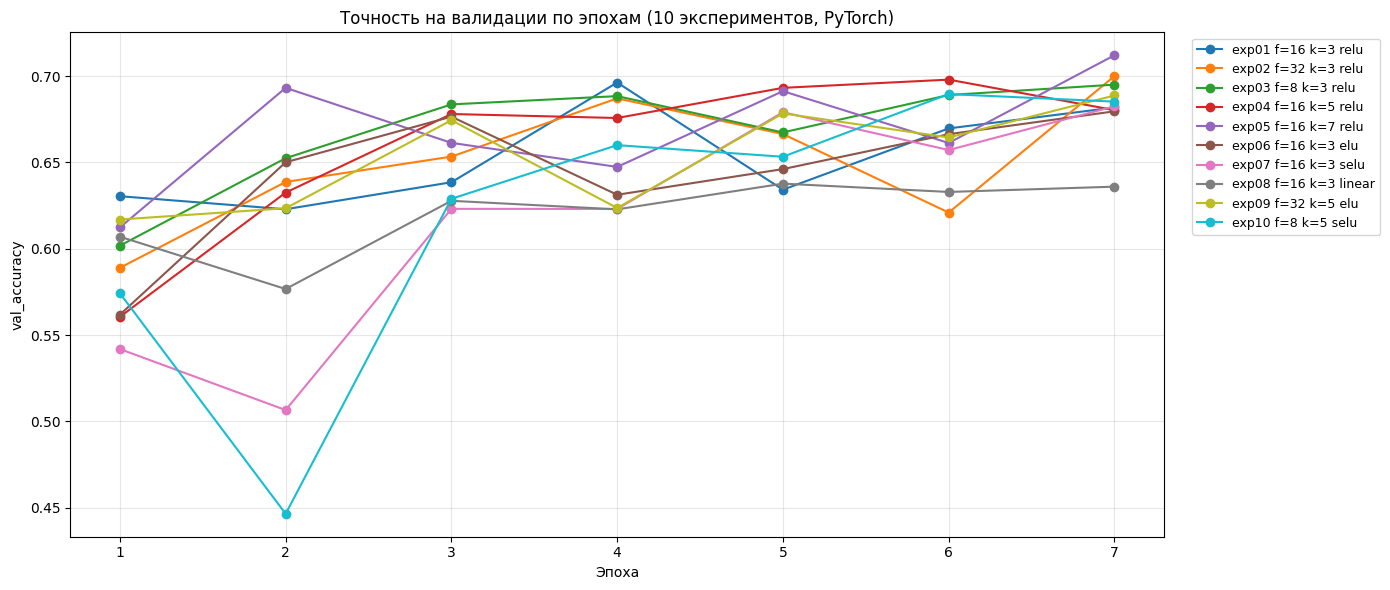

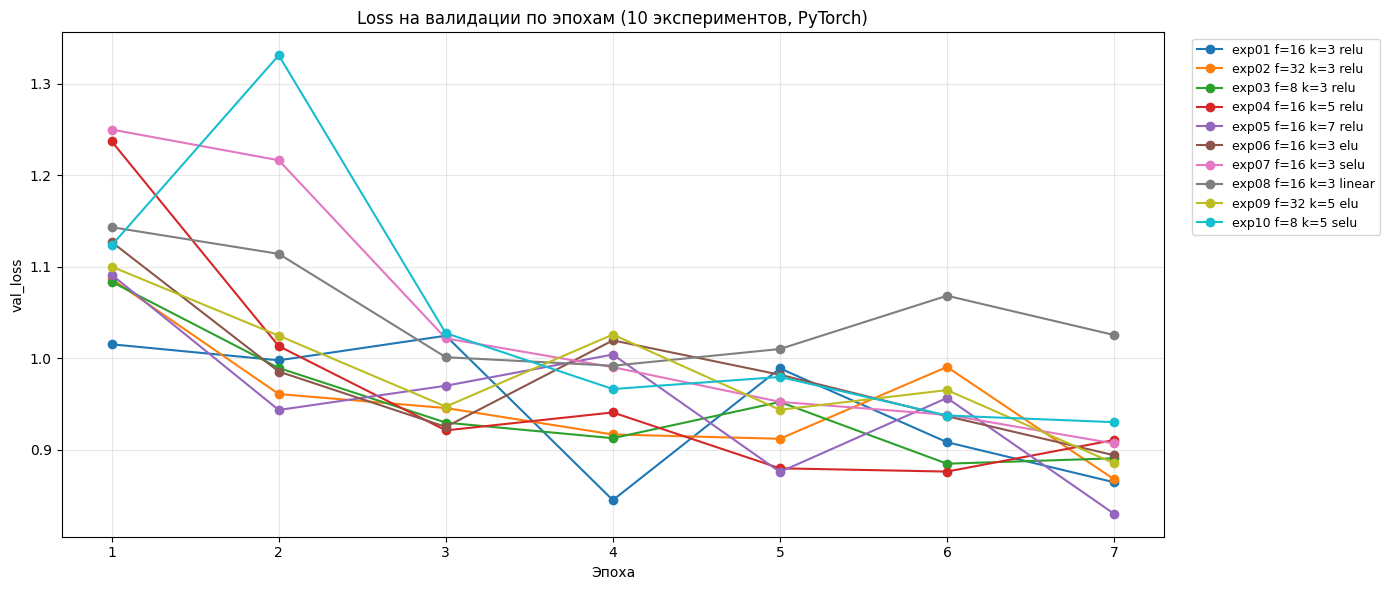

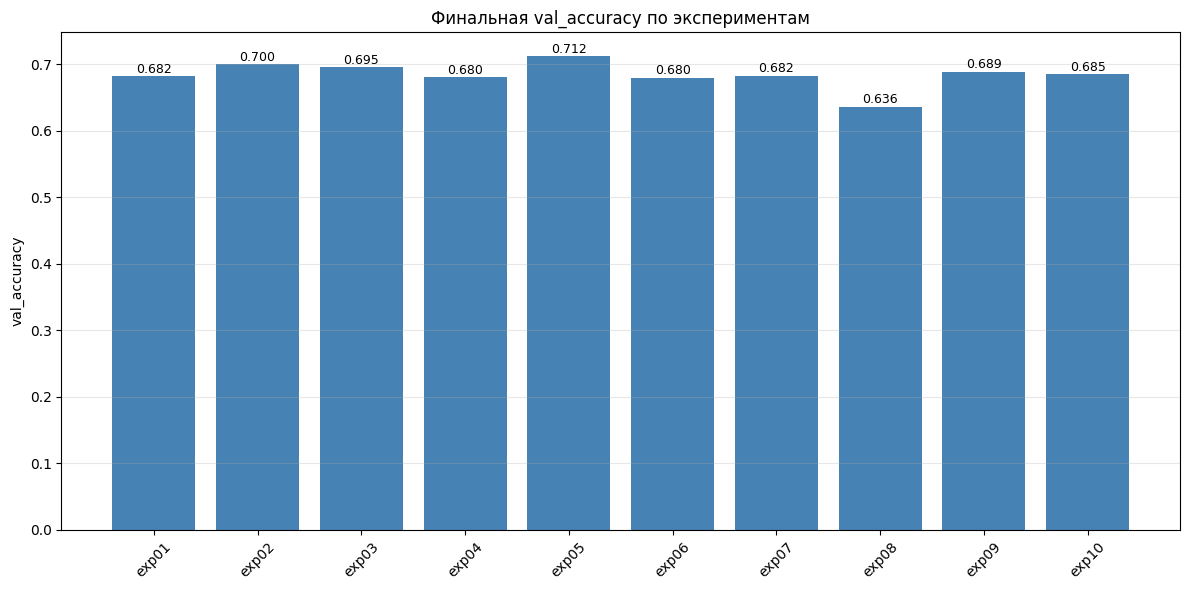


name    filters   kernel    activation    val_acc     val_loss    
--------------------------------------------------------------------------------
exp01   16        3         relu          0.6818      0.8643      
exp02   32        3         relu          0.6999      0.8676      
exp03   8         3         relu          0.6950      0.8905      
exp04   16        5         relu          0.6803      0.9105      
exp05   16        7         relu          0.7120      0.8299      
exp06   16        3         elu           0.6796      0.8939      
exp07   16        3         selu          0.6825      0.9067      
exp08   16        3         linear        0.6359      1.0252      
exp09   32        5         elu           0.6887      0.8851      
exp10   8         5         selu          0.6852      0.9300      

Лучший: exp05 — filters=16, kernel_size=7, activation=relu, val_acc=0.7120


In [ ]:
# 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
plt.figure(figsize=(14,6))
for r in results:
    plt.plot(range(1,EPOCHS+1), r['val_acc'], marker='o',
             label=f"{r['name']} f={r['filters']} k={r['kernel_size']} {r['activation']}")
plt.title('Точность на валидации по эпохам (10 экспериментов, PyTorch)')
plt.xlabel('Эпоха'); plt.ylabel('val_accuracy'); plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

plt.figure(figsize=(14,6))
for r in results:
    plt.plot(range(1,EPOCHS+1), r['val_loss'], marker='o',
             label=f"{r['name']} f={r['filters']} k={r['kernel_size']} {r['activation']}")
plt.title('Loss на валидации по эпохам (10 экспериментов, PyTorch)')
plt.xlabel('Эпоха'); plt.ylabel('val_loss'); plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

plt.figure(figsize=(12,6))
names=[r['name'] for r in results]; finals=[r['final_val_acc'] for r in results]
bars=plt.bar(names, finals, color='steelblue')
plt.title('Финальная val_accuracy по экспериментам')
plt.ylabel('val_accuracy'); plt.xticks(rotation=45)
for b,v in zip(bars,finals):
    plt.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=9)
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

print('\n'+'='*80)
print(f"{'name':<8}{'filters':<10}{'kernel':<10}{'activation':<14}{'val_acc':<12}{'val_loss':<12}")
print('-'*80)
for r in results:
    print(f"{r['name']:<8}{r['filters']:<10}{r['kernel_size']:<10}"
          f"{r['activation']:<14}{r['final_val_acc']:<12.4f}{r['final_val_loss']:<12.4f}")
print('='*80)
best = max(results, key=lambda r: r['final_val_acc'])
print(f"\nЛучший: {best['name']} — filters={best['filters']}, "
      f"kernel_size={best['kernel_size']}, activation={best['activation']}, "
      f"val_acc={best['final_val_acc']:.4f}")


  эпоха 1/7  train_loss=1.0092 acc=0.6305 | val_loss=1.0224 acc=0.6308
  эпоха 2/7  train_loss=0.7829 acc=0.7169 | val_loss=0.9584 acc=0.6439
  эпоха 3/7  train_loss=0.7174 acc=0.7437 | val_loss=0.9038 acc=0.6846
  эпоха 4/7  train_loss=0.6747 acc=0.7603 | val_loss=0.9246 acc=0.6926
  эпоха 5/7  train_loss=0.6480 acc=0.7714 | val_loss=0.8997 acc=0.6672
  эпоха 6/7  train_loss=0.6172 acc=0.7849 | val_loss=0.9013 acc=0.6966
  эпоха 7/7  train_loss=0.5955 acc=0.7931 | val_loss=0.8481 acc=0.7028


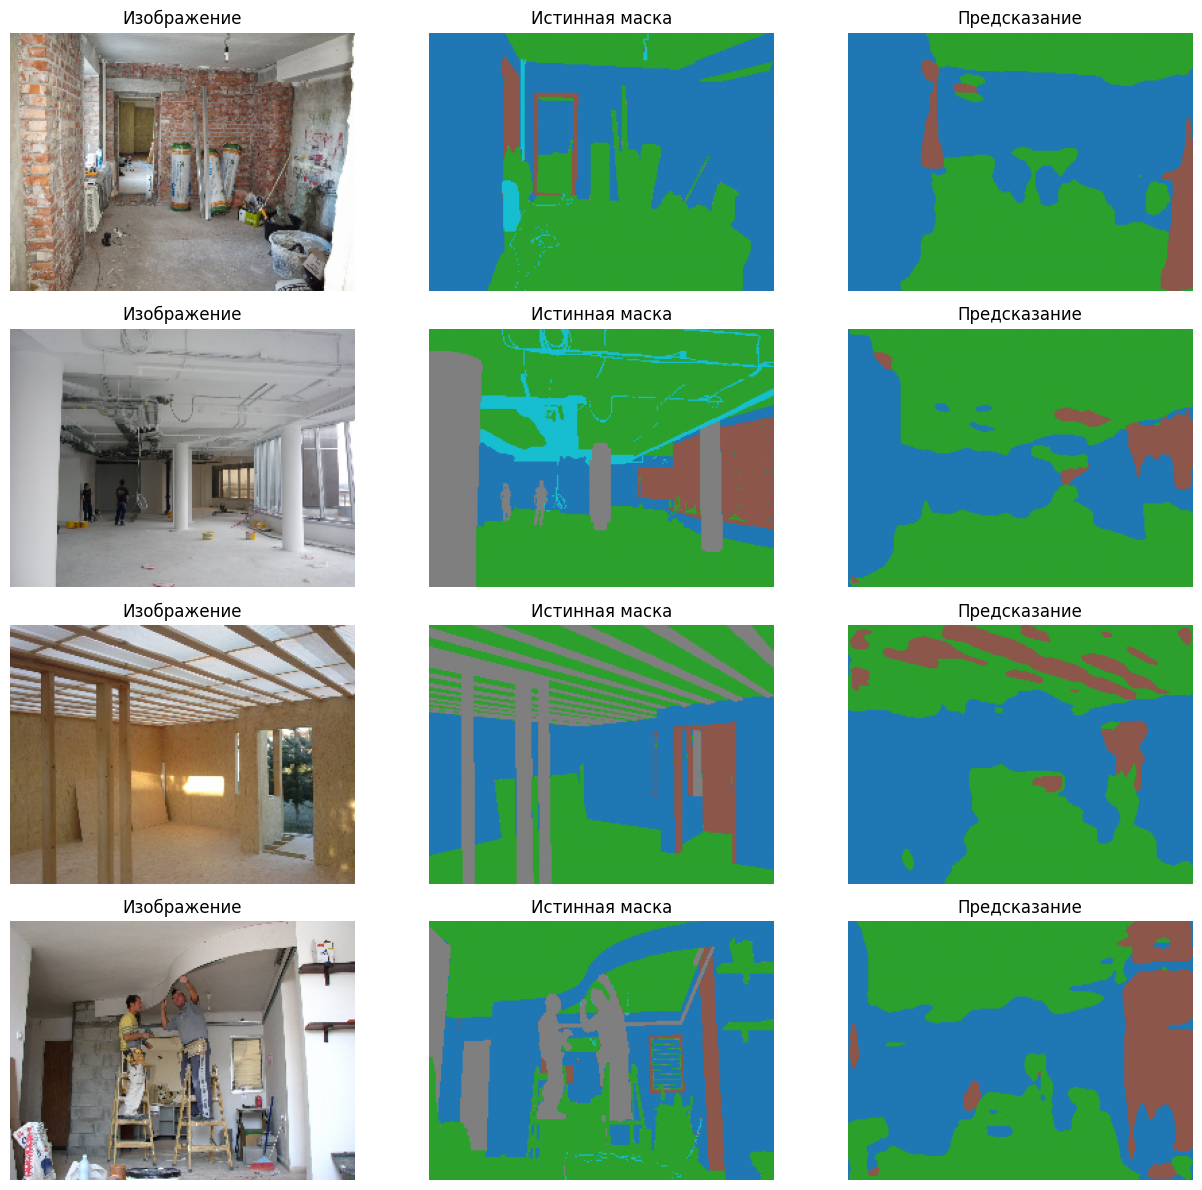

In [ ]:
# 5. ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ ЛУЧШЕЙ МОДЕЛИ
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

best_model = UNet(NUM_CLASSES, best['filters'], best['kernel_size'],
                  best['activation']).to(device)
_ = train_one(best_model)

best_model.eval()
n_show = 4
idxs = np.random.choice(len(xt_val), n_show, replace=False)
with torch.no_grad():
    xb = pad_to8(xt_val[idxs].to(device))
    logits = best_model(xb)
    pred = logits.argmax(1).cpu().numpy()[:, :IMG_H, :IMG_W]

imgs = xt_val[idxs].permute(0,2,3,1).numpy()      # (n,H,W,3) uint8
true = yt_val[idxs].numpy()

fig, axes = plt.subplots(n_show, 3, figsize=(13, 3.0*n_show))
for i in range(n_show):
    axes[i,0].imshow(imgs[i]);   axes[i,0].set_title('Изображение');    axes[i,0].axis('off')
    axes[i,1].imshow(true[i], cmap='tab10', vmin=0, vmax=NUM_CLASSES-1)
    axes[i,1].set_title('Истинная маска'); axes[i,1].axis('off')
    axes[i,2].imshow(pred[i], cmap='tab10', vmin=0, vmax=NUM_CLASSES-1)
    axes[i,2].set_title('Предсказание');   axes[i,2].axis('off')
plt.tight_layout(); plt.show()

del best_model, logits, xb
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
